In [23]:
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd

In [24]:
df = pd.read_csv('cleaned_dataset.csv')

In [25]:
print('data:->')
print(df.head(3))
print()
print('--------------------------------------------------------------------------------------------------')

print('datatypes:-> ')
print(df.info())
print()
print('---------------------------------------------------------------------------------------------------')


print('shape:-> ')
print(df.shape)
print()
print('---------------------------------------------------------------------------------------------------')

print('description:-> ')
print(df.describe(include='all'))
print()
print('---------------------------------------------------------------------------------------------------')

print('null count:-> ')
print(df.isnull().sum())
print()
print('---------------------------------------------------------------------------------------------------')

print('duplicate count:-> ')
print(df.duplicated().sum())
print()
print('---------------------------------------------------------------------------------------------------')

data:->
                   location  total_sqft  size   price
0  Electronic City Phase II      1056.0     2   39.07
1          Chikka Tirupathi      2600.0     4  120.00
2               Uttarahalli      1440.0     3   62.00

--------------------------------------------------------------------------------------------------
datatypes:-> 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12126 entries, 0 to 12125
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    12126 non-null  object 
 1   total_sqft  12126 non-null  float64
 2   size        12126 non-null  int64  
 3   price       12126 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 379.1+ KB
None

---------------------------------------------------------------------------------------------------
shape:-> 
(12126, 4)

---------------------------------------------------------------------------------------------------
description:-> 


<Axes: xlabel='total_sqft', ylabel='price'>

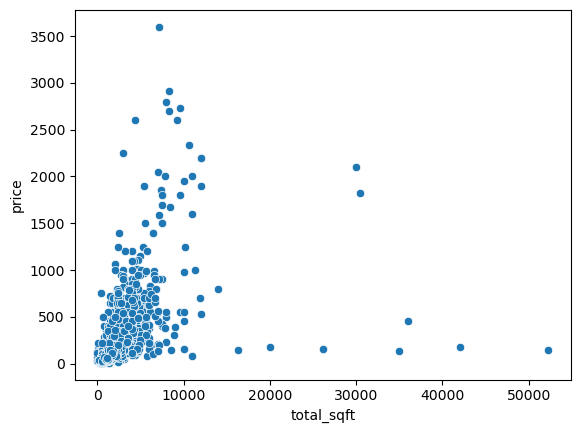

In [26]:
#total_sqft 
sns.scatterplot(x='total_sqft',y='price',data=df)

<Axes: xlabel='size', ylabel='price'>

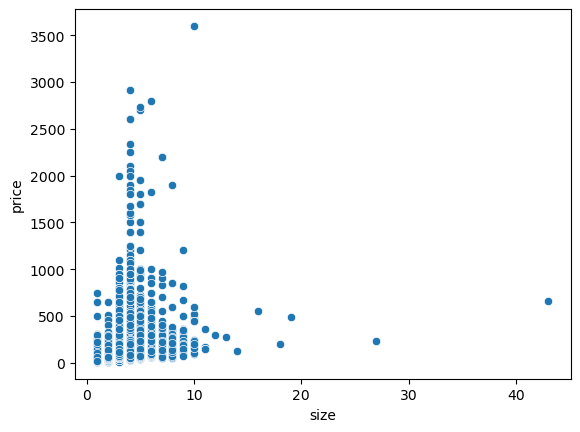

In [27]:
#size 
sns.scatterplot(x='size',y='price',data=df)

<Axes: xlabel='price', ylabel='Count'>

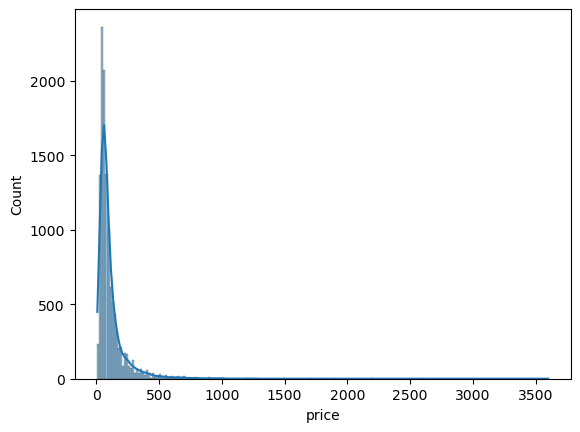

In [28]:
#price 
sns.histplot(df['price'], kde=True)

<Axes: xlabel='total_sqft', ylabel='Count'>

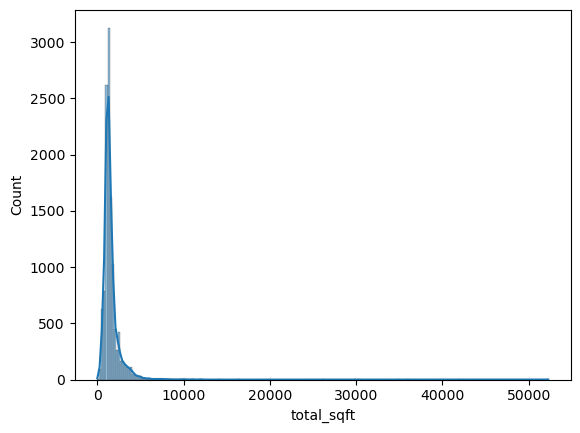

In [29]:
#total_sqft
sns.histplot(df['total_sqft'], kde=True)

<Axes: xlabel='size', ylabel='Count'>

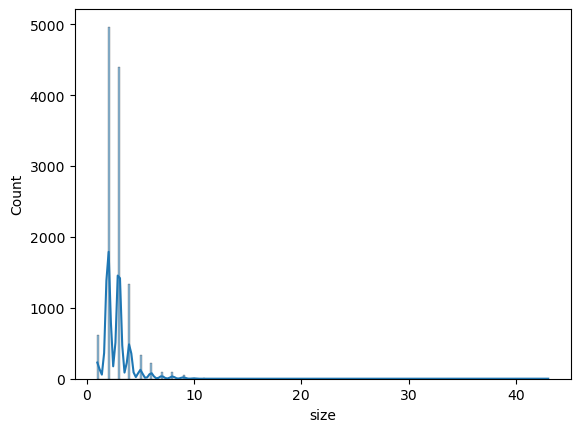

In [30]:
#size
sns.histplot(df['size'], kde=True)

<Axes: >

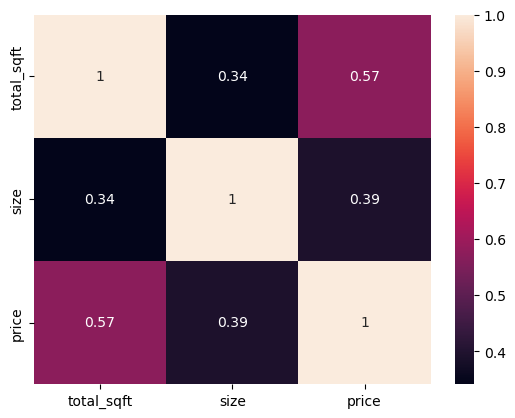

In [31]:
#heatmap
sns.heatmap(df.corr(numeric_only=True),annot=True)

# <font color='yellow'> Feature Engineering </font>

In [32]:
df = df[(df['total_sqft'] / df['size']) >= 300]

In [33]:
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft'] 
df.head(5)

,location,total_sqft,size,price,price_per_sqft
0,Electronic City Phase II,1056.0,2,39.07,3699.810606
1,Chikka Tirupathi,2600.0,4,120.00,4615.384615
2,Uttarahalli,1440.0,3,62.00,4305.555556
3,Lingadheeranahalli,1521.0,3,95.00,6245.890861
4,Kothanur,1200.0,2,51.00,4250.000000


In [34]:
df['price'] = df['price']*100000
df.head()

,location,total_sqft,size,price,price_per_sqft
0,Electronic City Phase II,1056.0,2,3907000.0,3699.810606
1,Chikka Tirupathi,2600.0,4,12000000.0,4615.384615
2,Uttarahalli,1440.0,3,6200000.0,4305.555556
3,Lingadheeranahalli,1521.0,3,9500000.0,6245.890861
4,Kothanur,1200.0,2,5100000.0,4250.000000


In [35]:
def remove_iqr_outliers(df):
  df_out = pd.DataFrame()

  for key, subdf in df.groupby('location'):
    q1 = subdf['price_per_sqft'].quantile(0.25)
    q3 = subdf['price_per_sqft'].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Filter within bounds
    reduced_df = subdf[
        (subdf['price_per_sqft'] >= lower_bound)
        & (subdf['price_per_sqft'] <= upper_bound)
    ]
    df_out = pd.concat([df_out, reduced_df], ignore_index=True)

  return df_out


# Apply IQR filtering
df = remove_iqr_outliers(df)
df.head()

,location,total_sqft,size,price,price_per_sqft
0,Devarachikkanahalli,1250.0,3,4400000.0,3520.000000
1,Devarachikkanahalli,1250.0,2,4000000.0,3200.000000
2,Devarachikkanahalli,1170.0,2,4000000.0,3418.803419
3,Devarachikkanahalli,1425.0,3,6500000.0,4561.403509
4,Devarachikkanahalli,947.0,2,4300000.0,4540.654699


In [36]:
df.to_csv('training_dataset.csv',index=False)
print('dataset saved successfully')

dataset saved successfully


# <font color='Yellow'>Training Model</font>

In [37]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['price','price_per_sqft'])
y= df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [38]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    StandardScaler,
)

li = LinearRegression()

# 1. Chain log transform -> scaler sequentially
num_pipeline = Pipeline([
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler()),
])

# 2. Feed the pipeline into ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, ['total_sqft', 'size']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['location']),
    ]
)

pipe = Pipeline([('preprocessor', preprocessor), ('model', li)])

pipe.fit(X_train, y_train)
li_training = pipe.predict(X_train)
y_pred_li = pipe.predict(X_test)

r2_score_li_train = r2_score(y_train,li_training)
r2_score_li_test = r2_score(y_test, y_pred_li)

print(r2_score_li_train)
print(r2_score_li_test)


0.6477373856327848
0.6882752577898656


In [46]:
#XGboost
from xgboost import XGBRegressor

pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor())
])



pipe_xgb.fit(X_train,y_train)
xgb_training = pipe_xgb.predict(X_train)
y_pred_xgb = pipe_xgb.predict(X_test)

r2_score_xgb_train = r2_score(y_train,xgb_training)
r2_score_xgb_test = r2_score(y_test,y_pred_xgb)


print(r2_score_xgb_train)
print(r2_score_xgb_test)

0.9110655599710309
0.8256854373794937


In [47]:
#DecisionTreeRegressor 
from sklearn.tree import DecisionTreeRegressor

pipe_dtr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor())
])

pipe_dtr.fit(X_train,y_train)
dtr_training = pipe_dtr.predict(X_train)
y_pred_dtr = pipe_dtr.predict(X_test)

r2_score_dtr_train = r2_score(y_train,dtr_training)
r2_score_dtr_test = r2_score(y_test,y_pred_dtr)


print(r2_score_dtr_train)
print(r2_score_dtr_test)

0.9790817911630527
0.7658650401436813


# <font color='yellow'>HyperParameter Tunning</font>

In [41]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV

# Define the search space using scipy.stats distributions
param_dist = {
    "model__n_estimators": randint(100, 1000),
    "model__max_depth": randint(3, 10),
    "model__learning_rate": uniform(0.01, 0.2),
    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4),
    "model__min_child_weight": randint(1, 10),
    "model__gamma": uniform(0, 0.5),
    "model__reg_alpha": uniform(0, 1),
    "model__reg_lambda": uniform(0.8, 2.0),
}

# If XGBoost is inside a Scikit-Learn Pipeline, prefix the parameters:
# e.g., "xgbregressor__n_estimators": randint(100, 1000)

random_search = RandomizedSearchCV(
    estimator=pipe_xgb,
    param_distributions=param_dist,  # Make sure this matches 'param_dist'
    n_iter=50,
    cv=5,
    n_jobs=-1,
    random_state=42,
)

random_search.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': <scipy.stats....002801E281050>, 'model__gamma': <scipy.stats....002801E281650>, 'model__learning_rate': <scipy.stats....002801E284AF0>, 'model__max_depth': <scipy.stats....002801E24E2C0>, ...}"
,n_iter,50
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [42]:
#testing the accuracy of hyperparamtered XGBoost
xgb_best_pipeline = random_search.best_estimator_
xgb_best_preds_test    = xgb_best_pipeline.predict(X_test)
xgb_best_preds_train    = xgb_best_pipeline.predict(X_train)


print(f"training R2 Score for xgb after hyperparameter tuning {r2_score(y_train, xgb_best_preds_train)}")
print(f"testing R2 Score for xgb after hyperparameter tuning {r2_score(y_test, xgb_best_preds_test)}")
print(f"MAE Score for xgb after hyperparameter tuning {mean_absolute_error(y_test, xgb_best_preds_test)}")

training R2 Score for xgb after hyperparameter tuning 0.9313597932684008
testing R2 Score for xgb after hyperparameter tuning 0.8153043256160897
MAE Score for xgb after hyperparameter tuning 2129338.9172535213


In [49]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor  # or DecisionTreeClassifier

# Search space for Decision Tree inside a Pipeline (prefixed with 'model__')
param_dist_dtr = {
    "model__criterion": ["squared_error", "absolute_error", "friedman_mse", "poisson"], # use ["gini", "entropy"] for classifier
    "model__max_depth": randint(3, 20),
    "model__min_samples_split": randint(2, 20),
    "model__min_samples_leaf": randint(1, 20),
    "model__max_features": [None, "sqrt", "log2", uniform(0.1, 0.9)],
    "model__min_impurity_decrease": uniform(0.0, 0.1),
    "model__ccp_alpha": uniform(0.0, 0.05), # Cost-complexity pruning
}

random_search_dtr = RandomizedSearchCV(
    estimator=pipe_dtr,  # Your Scikit-Learn pipeline object with DecisionTree
    param_distributions=param_dist_dt,
    n_iter=50,
    cv=5,
    n_jobs=-1,
    random_state=42,
    scoring="neg_mean_absolute_error" # or "neg_mean_squared_error" / "r2"
)

random_search_dtr.fit(X_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
90 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 663, in fit
    self._final_estimator.fit

,estimator,Pipeline(step...Regressor())])
,param_distributions,"{'model__ccp_alpha': <scipy.stats....00280307C1980>, 'model__criterion': ['squared_error', 'absolute_error', ...], 'model__max_depth': <scipy.stats....002801E287BD0>, 'model__max_features': [None, 'sqrt', ...], ...}"
,n_iter,50
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [50]:
#testing the accuracy of hyperparamtered XGBoost
dtr_best_pipeline = random_search_dtr.best_estimator_
dtr_best_preds_test    = dtr_best_pipeline.predict(X_test)
dtr_best_preds_train    = dtr_best_pipeline.predict(X_train)


print(f"training R2 Score for xgb after hyperparameter tuning {r2_score(y_train, dtr_best_preds_train)}")
print(f"testing R2 Score for xgb after hyperparameter tuning {r2_score(y_test, dtr_best_preds_test)}")
print(f"MAE Score for xgb after hyperparameter tuning {mean_absolute_error(y_test, dtr_best_preds_test)}")

training R2 Score for xgb after hyperparameter tuning 0.8358462644497233
testing R2 Score for xgb after hyperparameter tuning 0.7431014795534201
MAE Score for xgb after hyperparameter tuning 2605379.166250059


# <font color='yellow'>Model Evaluation and Saving The Model</font>

In [51]:
# Check the average actual price in test set
mean_price = y_test.mean()
median_price = y_test.median()

print(f"Mean Price: {mean_price:,.2f}")
print(f"Median Price: {median_price:,.2f}")

# Percentage Error relative to mean price
percentage_mae = (
    mean_absolute_error(y_test, xgb_best_preds_test) / mean_price
) * 100
print(f"Average Error Percentage: {percentage_mae:.2f}%")

Mean Price: 9,694,886.85
Median Price: 6,945,500.00
Average Error Percentage: 21.96%


In [52]:
from sklearn.metrics import mean_absolute_percentage_error

mape = (
    mean_absolute_percentage_error(y_test, xgb_best_preds_test) * 100
)
print(f"Standard MAPE: {mape:.2f}%")

Standard MAPE: 23.85%


In [45]:
import joblib

joblib.dump(xgb_best_pipeline, "xgb_model(1).pkl")

print("Model saved successfully as xgb_house_price_model.pkl!")

Model saved successfully as xgb_house_price_model.pkl!
